# Referencias

* https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

* https://github.com/zalandoresearch/fashion-mnist

* https://github.com/pranay414/Fashion-MNIST-Pytorch/blob/master/fashion_mnist.ipynb



In [2]:
# 1.0)
!pip3 install torch torchvision torchaudio torchviz

In [3]:
import os
import pickle
import datetime
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
import json

import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose

import google.colab
from google.colab import files

import time

In [4]:
transform = transforms.Compose([
                                transforms.ToTensor()
                                ,transforms.Normalize((0.5,), (0.5,))
                                #,transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ])
labels_name = {
    0: 'T-shirt/top',
    1: 'Trouer',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}
train_set = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

class NeuralNetwork(nn.Module):
    def __init__(self,nI, n1, n2, nO, p=0.2):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.full_W1 = nn.Linear(nI, n1)
        self.full_W2 = nn.Linear(n1, n2)
        self.full_W3 = nn.Linear(n2, nO)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p)

    def forward(self, x):
        # capa de entrada
        x = self.flatten(x)
        # capa oculta 1
        x = self.full_W1(x)
        x = self.relu(x)
        x = self.dropout(x)
        # capa oculta 2
        x = self.full_W2(x)
        x = self.relu(x)
        x = self.dropout(x)
        # capa de salida
        x = self.full_W3(x)
        return x

def train(data_loader, model, loss, optimizer):
    model.train()
    n_samples = len(data_loader.dataset)
    n_bach = len(data_loader)
    sum_loss = sum_correct = sum_sample = 0

    for batch, (X, Y) in enumerate(data_loader):
        X = X.to(device)
        Y = Y.to(device)
        batch_size = len(X)
        sum_sample += batch_size
        prediction = model(X)
        loss_value = loss(prediction, Y)
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        sum_loss += loss_value.item()*batch_size
        sum_correct += (prediction.argmax(1) == Y).type(torch.float).sum().item()
        #if batch % (n_bach/10) == 0:
        #    avrg_loss = sum_loss/sum_sample
        #    avrg_correct = sum_correct/sum_sample
        #    print(f"batch= {batch:>5d}, loss= {avrg_loss:>7f}")
    average_loss = sum_loss/sum_sample
    accuracy_correct = sum_correct/sum_sample
    return average_loss, accuracy_correct

def eval(data_loader, model, loss):
    model.eval()
    n_samples = len(data_loader.dataset)
    n_bach = len(data_loader)
    sum_loss = sum_correct = sum_sample = 0

    with torch.no_grad():
        for (X, Y) in data_loader:
            X = X.to(device)
            Y = Y.to(device)
            batch_size = len(X)
            sum_sample += batch_size
            prediction = model(X)
            loss_value = loss(prediction, Y)
            sum_loss += loss_value.item()*batch_size
            sum_correct += (prediction.argmax(1) == Y).type(torch.float).sum().item()

    average_loss = sum_loss/sum_sample
    accuracy_correct = sum_correct/sum_sample
    return average_loss, accuracy_correct

def avaliable_device():
    if torch.cuda.is_available(): return "cuda"
    else: return "cpu"

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.5MB/s]


In [ ]:
# parametros
n_epochs = 30
learning_rate = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Avaliable device: cuda


KeyboardInterrupt: 

i = 39738,
  label original  = Shirt
  label prdiction = Shirt


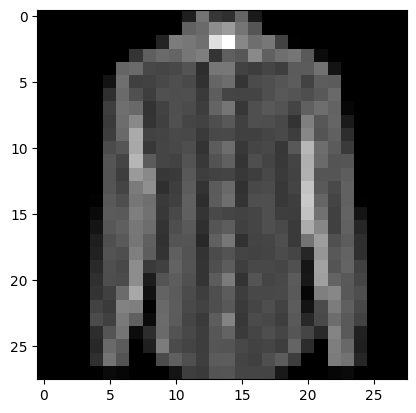

In [ ]:
i = np.random.randint(len(train_set))
image, label_o =  train_set[i]

model.eval()
with torch.no_grad():
    prediction = model(image.to(device))
    label_p = torch.argmax(nn.functional.softmax(prediction,1))
print(f"i = {i},\n  label original  = {labels_name[label_o]}\n  label prdiction = {labels_name[label_p.item()]}")
plt.imshow(image.squeeze(), cmap='Greys_r')

Avaliable device: cuda
Epoch 1/50: train loss=0.407, valid loss=0.446, train accuracy=0.851%, valid accuracy=0.837%
Epoch 2/50: train loss=0.368, valid loss=0.412, train accuracy=0.864%, valid accuracy=0.848%
Epoch 3/50: train loss=0.327, valid loss=0.381, train accuracy=0.880%, valid accuracy=0.864%
Epoch 4/50: train loss=0.317, valid loss=0.379, train accuracy=0.882%, valid accuracy=0.862%
Epoch 5/50: train loss=0.313, valid loss=0.371, train accuracy=0.885%, valid accuracy=0.866%
Epoch 6/50: train loss=0.286, valid loss=0.365, train accuracy=0.895%, valid accuracy=0.871%
Epoch 7/50: train loss=0.286, valid loss=0.361, train accuracy=0.894%, valid accuracy=0.871%
Epoch 8/50: train loss=0.278, valid loss=0.358, train accuracy=0.895%, valid accuracy=0.870%
Epoch 9/50: train loss=0.268, valid loss=0.351, train accuracy=0.900%, valid accuracy=0.872%
Epoch 10/50: train loss=0.256, valid loss=0.345, train accuracy=0.904%, valid accuracy=0.877%
Epoch 11/50: train loss=0.245, valid loss=0.34

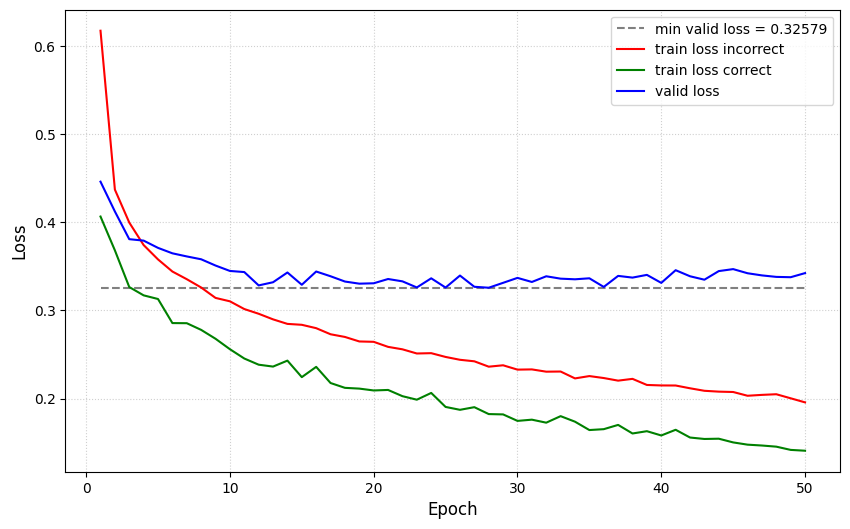

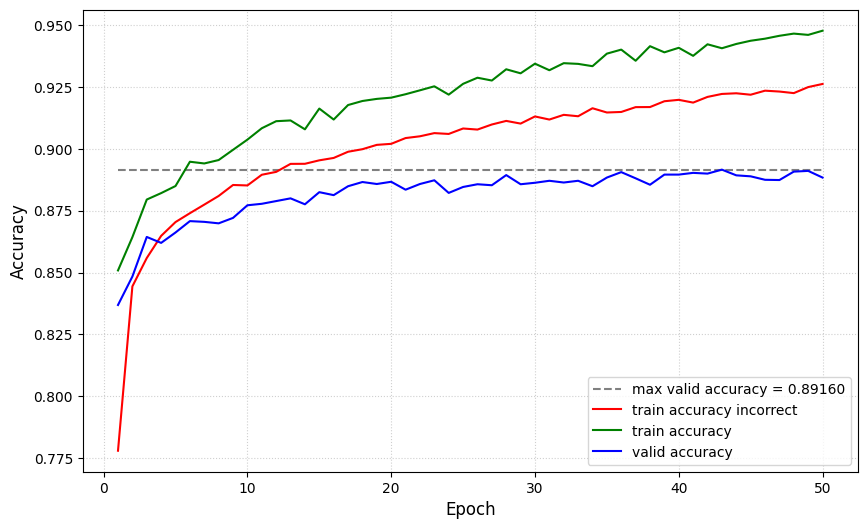

In [11]:
# Parametros - Caso ideal
n_epochs = 50
learning_rate = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
plt.figure(figsize=(10,6))
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss correct', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

plt.figure(figsize=(10,6))
max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

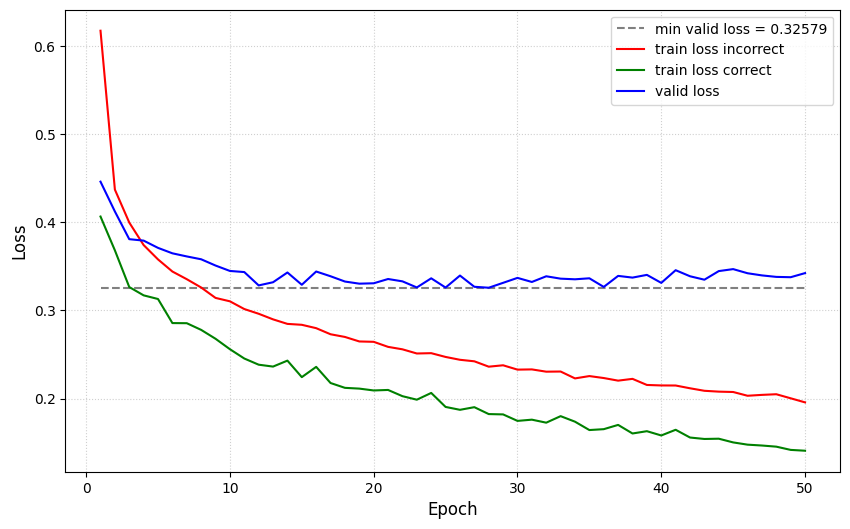

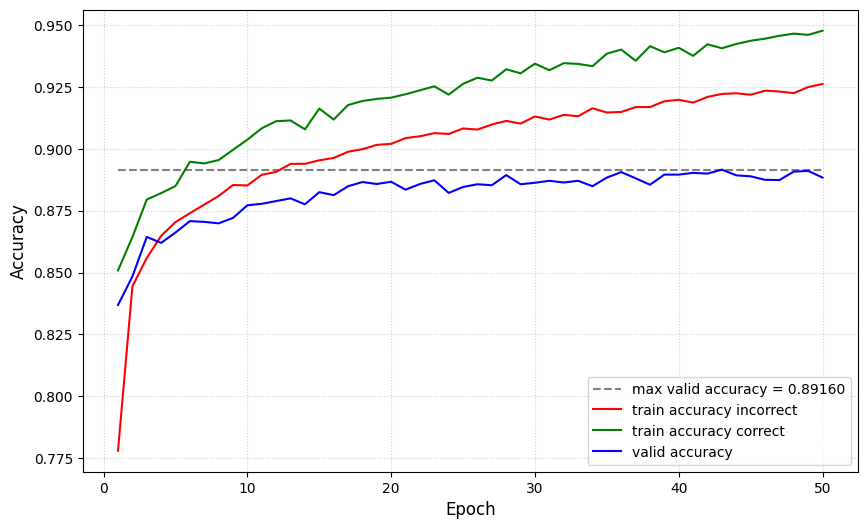

In [13]:
epoch = [i for i in range(1, n_epochs+1)]
plt.figure(figsize=(10,6))
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss correct', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

plt.figure(figsize=(10,6))
max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy correct', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# =====================
# Gráficos de pérdida y accuracy (caso ideal)
# =====================

epoch = [i for i in range(1, n_epochs+1)]

# ======= LOSS =======
min_loss = min(list_valid_loss)
plt.figure(figsize=(10,6))

# Línea horizontal con el mínimo loss de validación
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"Min valid loss = {min_loss:.5f}",
         c='gray', linestyle="--", linewidth=1.8)

# Curvas de pérdida
plt.plot(epoch, list_train_loss, label='Train loss (correct)',
         c='green', linestyle='--', linewidth=2)
plt.plot(epoch, list_valid_loss, label='Valid loss',
         c='blue', linestyle='-', linewidth=2)

# Ejes y formato
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Train vs Validation Loss', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ======= ACCURACY =======
max_acc = max(list_valid_accuracy)
plt.figure(figsize=(10,6))

# Línea horizontal con la mejor accuracy de validación
plt.plot(epoch, np.full(n_epochs, max_acc), label=f"Max valid accuracy = {max_acc:.2f}%",
         c='gray', linestyle="--", linewidth=1.8)

# Curvas de accuracy
plt.plot(epoch, list_train_accuracy, label='Train accuracy (correct)',
         c='green', linestyle='--', linewidth=2)
plt.plot(epoch, list_valid_accuracy, label='Valid accuracy',
         c='blue', linestyle='-', linewidth=2)
plt.plot(epoch, list_train_accuracy_incorrect, label='Train accuracy (incorrect)',
         c='red', linestyle=':', linewidth=1.8, alpha=0.7)

# Ejes y formato
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.title('Train vs Validation Accuracy', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# Lu -> Learning Rate y Optimizador

Avaliable device: cuda
LR=1e-03 | Epoch 1/50 | train loss=0.411, valid loss=0.448, train acc=0.851%, valid acc=0.838%
LR=1e-03 | Epoch 2/50 | train loss=0.380, valid loss=0.429, train acc=0.857%, valid acc=0.840%
LR=1e-03 | Epoch 3/50 | train loss=0.331, valid loss=0.382, train acc=0.880%, valid acc=0.861%
LR=1e-03 | Epoch 4/50 | train loss=0.315, valid loss=0.373, train acc=0.886%, valid acc=0.864%
LR=1e-03 | Epoch 5/50 | train loss=0.301, valid loss=0.366, train acc=0.889%, valid acc=0.867%
LR=1e-03 | Epoch 6/50 | train loss=0.293, valid loss=0.360, train acc=0.891%, valid acc=0.868%
LR=1e-03 | Epoch 7/50 | train loss=0.282, valid loss=0.357, train acc=0.895%, valid acc=0.872%
LR=1e-03 | Epoch 8/50 | train loss=0.274, valid loss=0.348, train acc=0.898%, valid acc=0.873%
LR=1e-03 | Epoch 9/50 | train loss=0.263, valid loss=0.340, train acc=0.901%, valid acc=0.875%
LR=1e-03 | Epoch 10/50 | train loss=0.259, valid loss=0.348, train acc=0.903%, valid acc=0.875%
LR=1e-03 | Epoch 11/50 | t

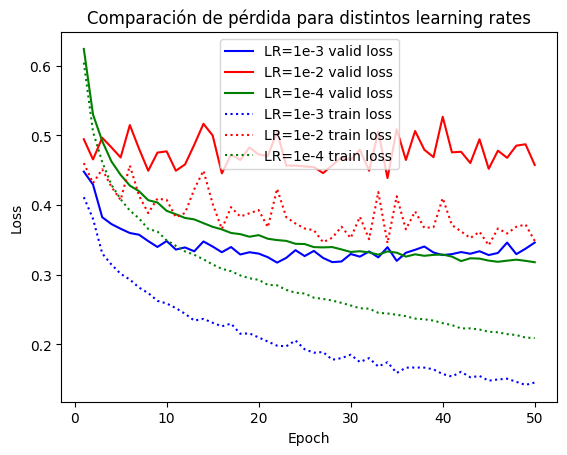

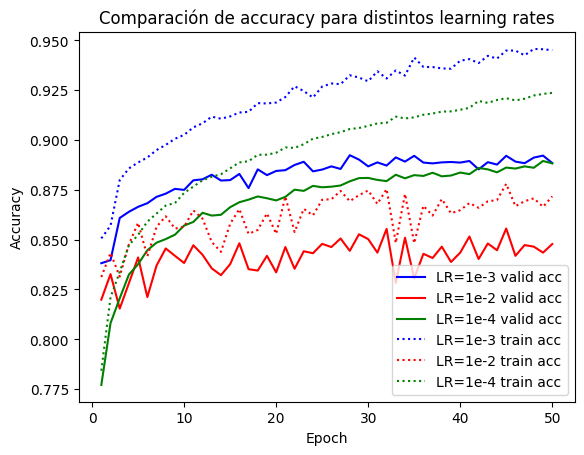

In [ ]:
# Comparación de tres learning rates
# ======================================
n_epochs = 50
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

# Casos con distintos learning rates
lr1 = 1e-3
lr2 = 1e-2
lr3 = 1e-4

# Listas para cada caso
lr1_train_loss, lr1_valid_loss, lr1_train_acc, lr1_valid_acc = [], [], [], []
lr2_train_loss, lr2_valid_loss, lr2_train_acc, lr2_valid_acc = [], [], [], []
lr3_train_loss, lr3_valid_loss, lr3_train_acc, lr3_valid_acc = [], [], [], []

# Loaders
train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle=True)

device = torch.device(avaliable_device())
print(f"Avaliable device: {device}")

# ======================================
# Función auxiliar para entrenar y evaluar
# ======================================
def train_and_evaluate(learning_rate):
    function_loss = nn.CrossEntropyLoss()
    model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model = model.to(device)

    list_train_loss, list_valid_loss = [], []
    list_train_accuracy, list_valid_accuracy = [], []

    t_i = time.time()
    for epoch in range(n_epochs):
        # entrenamiento
        train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
        # evaluación en train
        train_loss, train_accuracy = eval(train_loader, model, function_loss)
        # evaluación en validación
        valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)

        # guardar resultados
        list_train_loss.append(train_loss)
        list_train_accuracy.append(train_accuracy)
        list_valid_loss.append(valid_loss)
        list_valid_accuracy.append(valid_accuracy)

        print(f"LR={learning_rate:.0e} | Epoch {epoch+1}/{n_epochs} | "
              f"train loss={train_loss:.3f}, valid loss={valid_loss:.3f}, "
              f"train acc={train_accuracy:.3f}%, valid acc={valid_accuracy:.3f}%")

    print(f"Tiempo de ejecución (LR={learning_rate:.0e}): {(time.time()-t_i)/60:.2f} min\n")
    return list_train_loss, list_valid_loss, list_train_accuracy, list_valid_accuracy


# ======================================
# Entrenamientos para cada learning rate
# ======================================
lr1_train_loss, lr1_valid_loss, lr1_train_acc, lr1_valid_acc = train_and_evaluate(lr1)
lr2_train_loss, lr2_valid_loss, lr2_train_acc, lr2_valid_acc = train_and_evaluate(lr2)
lr3_train_loss, lr3_valid_loss, lr3_train_acc, lr3_valid_acc = train_and_evaluate(lr3)

# ======================================
# Gráficos comparativos
# ======================================
epoch = [i for i in range(1, n_epochs+1)]

# --- Loss ---
plt.plot(epoch, lr1_valid_loss, label='LR=1e-3 valid loss', linestyle='-', c='blue')
plt.plot(epoch, lr2_valid_loss, label='LR=1e-2 valid loss', linestyle='-', c='red')
plt.plot(epoch, lr3_valid_loss, label='LR=1e-4 valid loss', linestyle='-', c='green')

plt.plot(epoch, lr1_train_loss, label='LR=1e-3 train loss', linestyle=':', c='blue')
plt.plot(epoch, lr2_train_loss, label='LR=1e-2 train loss', linestyle=':', c='red')
plt.plot(epoch, lr3_train_loss, label='LR=1e-4 train loss', linestyle=':', c='green')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Comparación de pérdida para distintos learning rates')
plt.savefig("learning_rate_loss.png")
plt.show()

# --- Accuracy ---
plt.plot(epoch, lr1_valid_acc, label='LR=1e-3 valid acc', linestyle='-', c='blue')
plt.plot(epoch, lr2_valid_acc, label='LR=1e-2 valid acc', linestyle='-', c='red')
plt.plot(epoch, lr3_valid_acc, label='LR=1e-4 valid acc', linestyle='-', c='green')

plt.plot(epoch, lr1_train_acc, label='LR=1e-3 train acc', linestyle=':', c='blue')
plt.plot(epoch, lr2_train_acc, label='LR=1e-2 train acc', linestyle=':', c='red')
plt.plot(epoch, lr3_train_acc, label='LR=1e-4 train acc', linestyle=':', c='green')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Comparación de accuracy para distintos learning rates')
plt.savefig("learning_rate_accuracy.png")
plt.show()


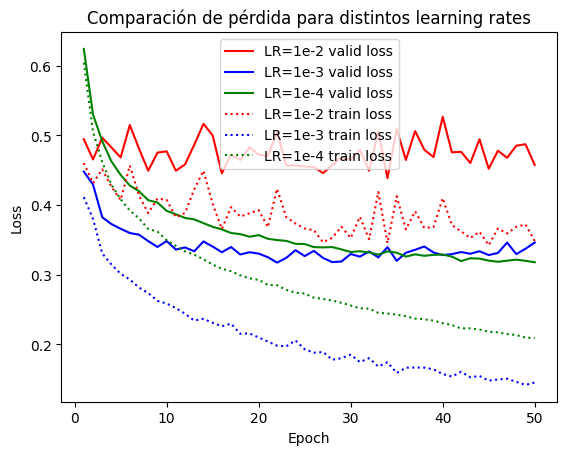

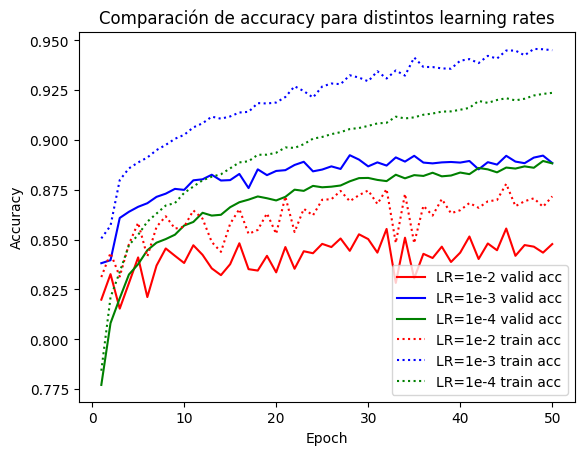

In [ ]:
# ======================================
# Gráficos comparativos
# ======================================
epoch = [i for i in range(1, n_epochs+1)]

# --- Loss ---
plt.plot(epoch, lr2_valid_loss, label='LR=1e-2 valid loss', linestyle='-', c='red')
plt.plot(epoch, lr1_valid_loss, label='LR=1e-3 valid loss', linestyle='-', c='blue')
plt.plot(epoch, lr3_valid_loss, label='LR=1e-4 valid loss', linestyle='-', c='green')

plt.plot(epoch, lr2_train_loss, label='LR=1e-2 train loss', linestyle=':', c='red')
plt.plot(epoch, lr1_train_loss, label='LR=1e-3 train loss', linestyle=':', c='blue')
plt.plot(epoch, lr3_train_loss, label='LR=1e-4 train loss', linestyle=':', c='green')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Comparación de pérdida para distintos learning rates')
plt.savefig("learning_rate_loss.png")
plt.show()

# --- Accuracy ---
plt.plot(epoch, lr2_valid_acc, label='LR=1e-2 valid acc', linestyle='-', c='red')
plt.plot(epoch, lr1_valid_acc, label='LR=1e-3 valid acc', linestyle='-', c='blue')
plt.plot(epoch, lr3_valid_acc, label='LR=1e-4 valid acc', linestyle='-', c='green')

plt.plot(epoch, lr2_train_acc, label='LR=1e-2 train acc', linestyle=':', c='red')
plt.plot(epoch, lr1_train_acc, label='LR=1e-3 train acc', linestyle=':', c='blue')
plt.plot(epoch, lr3_train_acc, label='LR=1e-4 train acc', linestyle=':', c='green')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Comparación de accuracy para distintos learning rates')
plt.savefig("learning_rate_accuracy.png")
plt.show()

Avaliable device: cuda
Epoch 1/50: train loss=0.444, valid loss=0.482, train accuracy=0.841%, valid accuracy=0.826%
Epoch 2/50: train loss=0.463, valid loss=0.494, train accuracy=0.838%, valid accuracy=0.828%
Epoch 3/50: train loss=0.450, valid loss=0.502, train accuracy=0.830%, valid accuracy=0.813%
Epoch 4/50: train loss=0.453, valid loss=0.509, train accuracy=0.838%, valid accuracy=0.823%
Epoch 5/50: train loss=0.452, valid loss=0.507, train accuracy=0.831%, valid accuracy=0.819%
Epoch 6/50: train loss=0.439, valid loss=0.499, train accuracy=0.840%, valid accuracy=0.823%
Epoch 7/50: train loss=0.438, valid loss=0.497, train accuracy=0.849%, valid accuracy=0.831%
Epoch 8/50: train loss=0.402, valid loss=0.464, train accuracy=0.858%, valid accuracy=0.841%
Epoch 9/50: train loss=0.398, valid loss=0.464, train accuracy=0.859%, valid accuracy=0.843%
Epoch 10/50: train loss=0.436, valid loss=0.494, train accuracy=0.837%, valid accuracy=0.817%
Epoch 11/50: train loss=0.465, valid loss=0.52

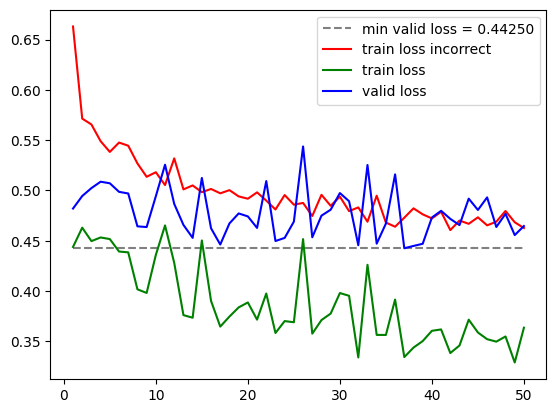

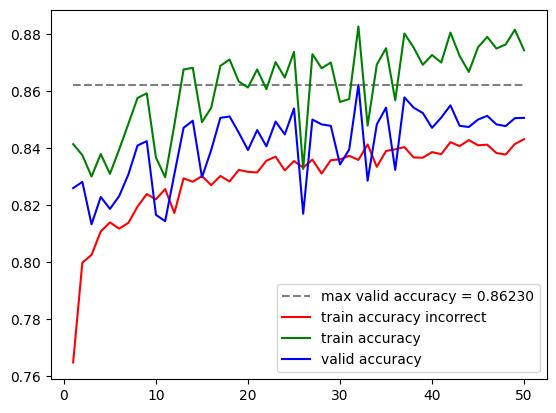

In [ ]:
# Parametros - learning_rate 1e-2
n_epochs = 50
learning_rate = 1e-2
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Avaliable device: cuda
Epoch 1/50: train loss=0.599, valid loss=0.619, train accuracy=0.789%, valid accuracy=0.778%
Epoch 2/50: train loss=0.503, valid loss=0.528, train accuracy=0.820%, valid accuracy=0.809%
Epoch 3/50: train loss=0.455, valid loss=0.484, train accuracy=0.838%, valid accuracy=0.823%
Epoch 4/50: train loss=0.429, valid loss=0.461, train accuracy=0.845%, valid accuracy=0.832%
Epoch 5/50: train loss=0.410, valid loss=0.442, train accuracy=0.851%, valid accuracy=0.838%
Epoch 6/50: train loss=0.392, valid loss=0.428, train accuracy=0.858%, valid accuracy=0.843%
Epoch 7/50: train loss=0.378, valid loss=0.416, train accuracy=0.862%, valid accuracy=0.847%
Epoch 8/50: train loss=0.369, valid loss=0.409, train accuracy=0.865%, valid accuracy=0.850%
Epoch 9/50: train loss=0.360, valid loss=0.401, train accuracy=0.870%, valid accuracy=0.854%
Epoch 10/50: train loss=0.348, valid loss=0.393, train accuracy=0.873%, valid accuracy=0.857%
Epoch 11/50: train loss=0.344, valid loss=0.39

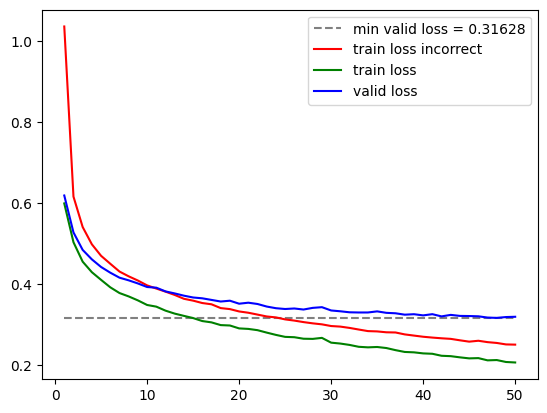

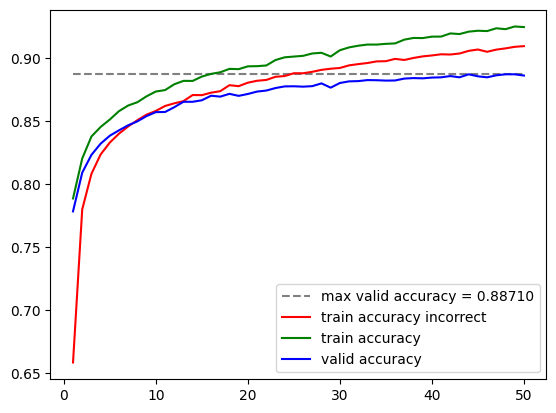

In [ ]:
# Parametros - learning_rate 1e-4
n_epochs = 50
learning_rate = 1e-4
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Dispositivo disponible: cuda

Entrenando con SGD...
SGD | Epoch 1/50 | Train loss=2.229 | Valid loss=2.130 | Train acc=0.215% | Valid acc=0.383%
SGD | Epoch 2/50 | Train loss=2.013 | Valid loss=1.836 | Train acc=0.381% | Valid acc=0.504%
SGD | Epoch 3/50 | Train loss=1.702 | Valid loss=1.489 | Train acc=0.455% | Valid acc=0.582%
SGD | Epoch 4/50 | Train loss=1.419 | Valid loss=1.231 | Train acc=0.525% | Valid acc=0.667%
SGD | Epoch 5/50 | Train loss=1.230 | Valid loss=1.066 | Train acc=0.577% | Valid acc=0.688%
SGD | Epoch 6/50 | Train loss=1.107 | Valid loss=0.960 | Train acc=0.613% | Valid acc=0.701%
SGD | Epoch 7/50 | Train loss=1.023 | Valid loss=0.887 | Train acc=0.634% | Valid acc=0.715%
SGD | Epoch 8/50 | Train loss=0.962 | Valid loss=0.834 | Train acc=0.655% | Valid acc=0.724%
SGD | Epoch 9/50 | Train loss=0.913 | Valid loss=0.795 | Train acc=0.669% | Valid acc=0.730%
SGD | Epoch 10/50 | Train loss=0.873 | Valid loss=0.764 | Train acc=0.682% | Valid acc=0.737%
SGD | Epoch 11/50

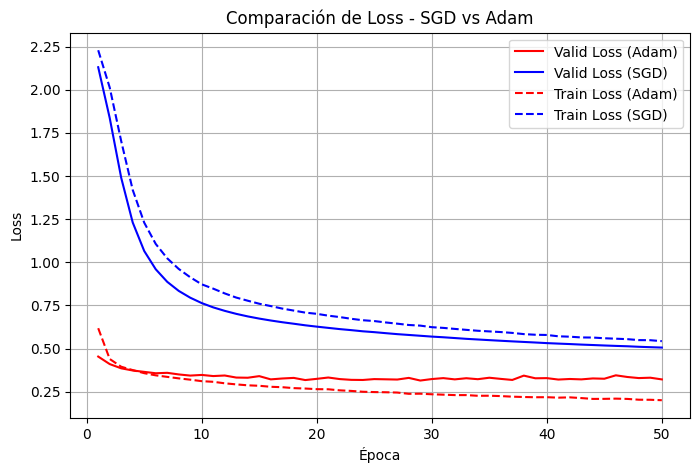

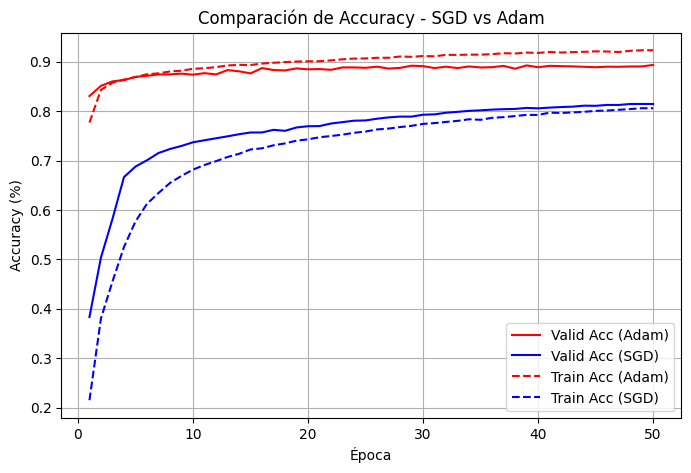

In [ ]:
# ===========================
# COMPARACIÓN SGD vs ADAM
# ===========================

n_epochs = 50
learning_rate = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle=True)
function_loss = nn.CrossEntropyLoss()
device = torch.device(avaliable_device())

# =====================
# Función para entrenar y evaluar un modelo
# =====================
def run_training(optimizer_name):
    model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout).to(device)

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Optimizador no reconocido")

    list_train_loss = []
    list_valid_loss = []
    list_train_acc = []
    list_valid_acc = []

    for epoch in range(n_epochs):
        # Entrenamiento
        train_loss, train_acc = train(train_loader, model, function_loss, optimizer)
        list_train_loss.append(train_loss)
        list_train_acc.append(train_acc)

        # Evaluación
        valid_loss, valid_acc = eval(valid_loader, model, function_loss)
        list_valid_loss.append(valid_loss)
        list_valid_acc.append(valid_acc)

        print(f"{optimizer_name} | Epoch {epoch+1}/{n_epochs} | Train loss={train_loss:.3f} | Valid loss={valid_loss:.3f} | Train acc={train_acc:.3f}% | Valid acc={valid_acc:.3f}%")

    return list_train_loss, list_valid_loss, list_train_acc, list_valid_acc

# =====================
# Entrenar ambos modelos
# =====================
print(f"Dispositivo disponible: {device}\n")

print("Entrenando con SGD...")
train_loss_sgd, valid_loss_sgd, train_acc_sgd, valid_acc_sgd = run_training("SGD")

print("\nEntrenando con Adam...")
train_loss_adam, valid_loss_adam, train_acc_adam, valid_acc_adam = run_training("Adam")

# =====================
# Gráficos comparativos
# =====================
epochs = range(1, n_epochs+1)

# --- Gráfico de pérdida ---
plt.figure(figsize=(8,5))
plt.plot(epochs, valid_loss_adam, label='Valid Loss (Adam)', color='red')
plt.plot(epochs, valid_loss_sgd, label='Valid Loss (SGD)', color='blue')
plt.plot(epochs, train_loss_adam, label='Train Loss (Adam)', color='red', linestyle='--')
plt.plot(epochs, train_loss_sgd, label='Train Loss (SGD)', color='blue', linestyle='--')
plt.title('Comparación de Loss - SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfico de accuracy ---
plt.figure(figsize=(8,5))
plt.plot(epochs, valid_acc_adam, label='Valid Acc (Adam)', color='red')
plt.plot(epochs, valid_acc_sgd, label='Valid Acc (SGD)', color='blue')
plt.plot(epochs, train_acc_adam, label='Train Acc (Adam)', color='red', linestyle='--')
plt.plot(epochs, train_acc_sgd, label='Train Acc (SGD)', color='blue', linestyle='--')
plt.title('Comparación de Accuracy - SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =====================
# Gráficos comparativos
# =====================
epochs = range(1, n_epochs+1)

# --- Gráfico de pérdida ---
plt.figure(figsize=(8,5))
plt.plot(epochs, valid_loss_sgd, label='Valid Loss (SGD)', color='blue')
plt.plot(epochs, valid_loss_adam, label='Valid Loss (Adam)', color='orange')
plt.plot(epochs, train_loss_sgd, label='Train Loss (SGD)', color='blue', linestyle='--')
plt.plot(epochs, train_loss_adam, label='Train Loss (Adam)', color='orange', linestyle='--')
plt.title('Comparación de Loss - SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfico de accuracy ---
plt.figure(figsize=(8,5))
plt.plot(epochs, valid_acc_sgd, label='Valid Acc (SGD)', color='blue')
plt.plot(epochs, valid_acc_adam, label='Valid Acc (Adam)', color='orange')
plt.plot(epochs, train_acc_sgd, label='Train Acc (SGD)', color='blue', linestyle='--')
plt.plot(epochs, train_acc_adam, label='Train Acc (Adam)', color='orange', linestyle='--')
plt.title('Comparación de Accuracy - SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Andre -> Número de nueronas - Número de épocas

In [ ]:
# distintos numeros de neuronas
n_epochs = 50
learning_rate = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
output_layer_size = 10     # no cambiar

c1_hidden_layer_1_size = 64
c1_hidden_layer_2_size = 32

c2_hidden_layer_1_size = 128
c2_hidden_layer_2_size = 64

c3_hidden_layer_1_size = 512
c3_hidden_layer_2_size = 256

c1_list_train_loss_incorrect = []
c1_list_train_accuracy_incorrect = []
c1_list_train_loss = []
c1_list_train_accuracy = []
c1_list_valid_loss = []
c1_list_valid_accuracy = []

c2_list_train_loss_incorrect = []
c2_list_train_accuracy_incorrect = []
c2_list_train_loss = []
c2_list_train_accuracy = []
c2_list_valid_loss = []
c2_list_valid_accuracy = []

c3_list_train_loss_incorrect = []
c3_list_train_accuracy_incorrect = []
c3_list_train_loss = []
c3_list_train_accuracy = []
c3_list_valid_loss = []
c3_list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)

c1_function_loss = nn.CrossEntropyLoss()
c1_model = NeuralNetwork(input_layer_size, c1_hidden_layer_1_size, c1_hidden_layer_2_size, output_layer_size, dropout)
c1_optimizer = torch.optim.Adam(c1_model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
c1_model = c1_model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    c1_train_loss_incorrect, c1_train_accuracy_incorrect = train(train_loader, c1_model, c1_function_loss, c1_optimizer)
    c1_list_train_loss_incorrect.append(c1_train_loss_incorrect)
    c1_list_train_accuracy_incorrect.append(c1_train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    c1_train_loss, c1_train_accuracy = eval(train_loader, c1_model, c1_function_loss)
    c1_list_train_loss.append(c1_train_loss)
    c1_list_train_accuracy.append(c1_train_accuracy)
    # valido con el conjunto de testeo
    c1_valid_loss, c1_valid_accuracy = eval(valid_loader, c1_model, c1_function_loss)
    c1_list_valid_loss.append(c1_valid_loss)
    c1_list_valid_accuracy.append(c1_valid_accuracy)
#'''
    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(c1_train_loss),
            "valid loss={:.3f},".format(c1_valid_loss),
            "train accuracy={:.3f}%,".format(c1_train_accuracy),
            "valid accuracy={:.3f}%".format(c1_valid_accuracy))
#'''
print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

c2_function_loss = nn.CrossEntropyLoss()
c2_model = NeuralNetwork(input_layer_size, c2_hidden_layer_1_size, c2_hidden_layer_2_size, output_layer_size, dropout)
c2_optimizer = torch.optim.Adam(c2_model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
c2_model = c2_model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    c2_train_loss_incorrect, c2_train_accuracy_incorrect = train(train_loader, c2_model, c2_function_loss, c2_optimizer)
    c2_list_train_loss_incorrect.append(c2_train_loss_incorrect)
    c2_list_train_accuracy_incorrect.append(c2_train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    c2_train_loss, c2_train_accuracy = eval(train_loader, c2_model, c2_function_loss)
    c2_list_train_loss.append(c2_train_loss)
    c2_list_train_accuracy.append(c2_train_accuracy)
    # valido con el conjunto de testeo
    c2_valid_loss, c2_valid_accuracy = eval(valid_loader, c2_model, c2_function_loss)
    c2_list_valid_loss.append(c2_valid_loss)
    c2_list_valid_accuracy.append(c2_valid_accuracy)
#'''
    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(c2_train_loss),
            "valid loss={:.3f},".format(c2_valid_loss),
            "train accuracy={:.3f}%,".format(c2_train_accuracy),
            "valid accuracy={:.3f}%".format(c2_valid_accuracy))
#'''
print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

c3_function_loss = nn.CrossEntropyLoss()
c3_model = NeuralNetwork(input_layer_size, c3_hidden_layer_1_size, c3_hidden_layer_2_size, output_layer_size, dropout)
c3_optimizer = torch.optim.Adam(c3_model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
c3_model = c3_model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    c3_train_loss_incorrect, c3_train_accuracy_incorrect = train(train_loader, c3_model, c3_function_loss, c3_optimizer)
    c3_list_train_loss_incorrect.append(c3_train_loss_incorrect)
    c3_list_train_accuracy_incorrect.append(c3_train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    c3_train_loss, c3_train_accuracy = eval(train_loader, c3_model, c3_function_loss)
    c3_list_train_loss.append(c3_train_loss)
    c3_list_train_accuracy.append(c3_train_accuracy)
    # valido con el conjunto de testeo
    c3_valid_loss, c3_valid_accuracy = eval(valid_loader, c3_model, c3_function_loss)
    c3_list_valid_loss.append(c3_valid_loss)
    c3_list_valid_accuracy.append(c3_valid_accuracy)
#'''
    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(c3_train_loss),
            "valid loss={:.3f},".format(c3_valid_loss),
            "train accuracy={:.3f}%,".format(c3_train_accuracy),
            "valid accuracy={:.3f}%".format(c3_valid_accuracy))
#'''
print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")


Avaliable device: cpu
Epoch 1/50: train loss=0.447, valid loss=0.476, train accuracy=0.838%, valid accuracy=0.827%
Epoch 2/50: train loss=0.397, valid loss=0.437, train accuracy=0.854%, valid accuracy=0.838%
Epoch 3/50: train loss=0.365, valid loss=0.412, train accuracy=0.865%, valid accuracy=0.849%
Epoch 4/50: train loss=0.355, valid loss=0.405, train accuracy=0.868%, valid accuracy=0.850%
Epoch 5/50: train loss=0.338, valid loss=0.391, train accuracy=0.875%, valid accuracy=0.857%
Epoch 6/50: train loss=0.328, valid loss=0.389, train accuracy=0.878%, valid accuracy=0.859%
Epoch 7/50: train loss=0.315, valid loss=0.377, train accuracy=0.885%, valid accuracy=0.860%
Epoch 8/50: train loss=0.306, valid loss=0.374, train accuracy=0.885%, valid accuracy=0.864%
Epoch 9/50: train loss=0.297, valid loss=0.363, train accuracy=0.892%, valid accuracy=0.868%
Epoch 10/50: train loss=0.288, valid loss=0.360, train accuracy=0.894%, valid accuracy=0.872%
Epoch 11/50: train loss=0.294, valid loss=0.370

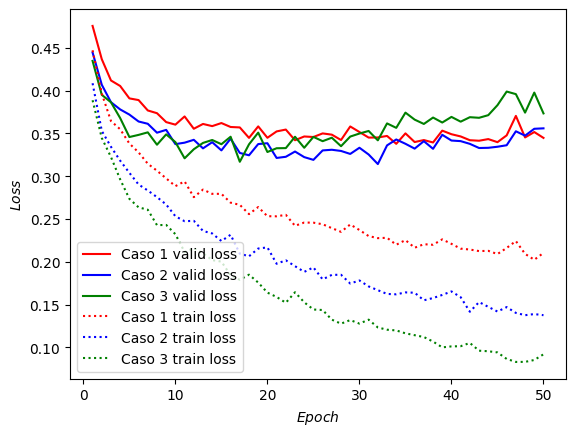

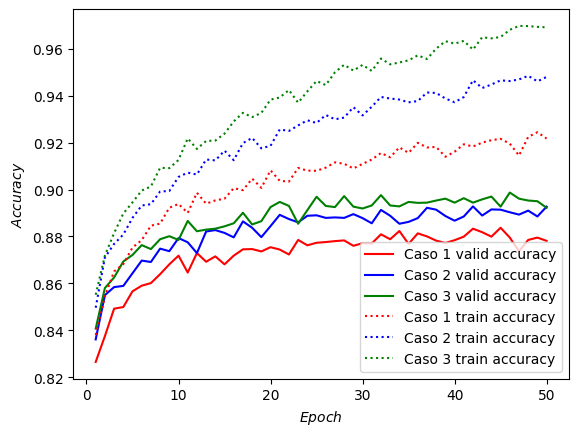

In [ ]:
# en el caption hay que agregar los distinto tamaños de las capas

epoch = [i for i in range(1, n_epochs+1)]c2_train_accuracy

plt.plot(epoch, c1_list_valid_loss, label='Caso 1 valid loss',  linestyle="-", c='red')
plt.plot(epoch, c2_list_valid_loss, label='Caso 2 valid loss',  linestyle="-", c='blue')
plt.plot(epoch, c3_list_valid_loss, label='Caso 3 valid loss',  linestyle="-", c='green')

plt.plot(epoch, c1_list_train_loss, label='Caso 1 train loss', linestyle=":", c='red')
plt.plot(epoch, c2_list_train_loss, label='Caso 2 train loss', linestyle=":", c='blue')
plt.plot(epoch, c3_list_train_loss, label='Caso 3 train loss', linestyle=":", c='green')

#plt.title('Perdida para los distintos tamaños de capas')
plt.xlabel('$Epoch$')
plt.ylabel('$Loss$')
plt.legend()
plt.savefig("n_capas_loss.png")
plt.show()


plt.plot(epoch, c1_list_valid_accuracy, label='Caso 1 valid accuracy', linestyle="-",c='red')
plt.plot(epoch, c2_list_valid_accuracy, label='Caso 2 valid accuracy', linestyle="-",c='blue')
plt.plot(epoch, c3_list_valid_accuracy, label='Caso 3 valid accuracy', linestyle="-",c='green')

plt.plot(epoch, c1_list_train_accuracy, label='Caso 1 train accuracy', linestyle=":", c='red')
plt.plot(epoch, c2_list_train_accuracy, label='Caso 2 train accuracy', linestyle=":", c='blue')
plt.plot(epoch, c3_list_train_accuracy, label='Caso 3 train accuracy', linestyle=":", c='green')

#plt.title('Precisión para los distintos tamaños de capas')
plt.xlabel('$Epoch$')
plt.ylabel('$Accuracy$')
plt.legend()
plt.savefig("n_capas_accuracy.png")
plt.show()

Avaliable device: cuda
Epoch 1/30: train loss=0.440, valid loss=0.479, train accuracy=0.835%, valid accuracy=0.820%
Epoch 2/30: train loss=0.361, valid loss=0.406, train accuracy=0.866%, valid accuracy=0.852%
Epoch 3/30: train loss=0.330, valid loss=0.385, train accuracy=0.878%, valid accuracy=0.862%
Epoch 4/30: train loss=0.321, valid loss=0.372, train accuracy=0.881%, valid accuracy=0.864%
Epoch 5/30: train loss=0.311, valid loss=0.375, train accuracy=0.885%, valid accuracy=0.866%
Epoch 6/30: train loss=0.290, valid loss=0.355, train accuracy=0.894%, valid accuracy=0.874%
Epoch 7/30: train loss=0.278, valid loss=0.345, train accuracy=0.897%, valid accuracy=0.878%
Epoch 8/30: train loss=0.281, valid loss=0.359, train accuracy=0.892%, valid accuracy=0.871%
Epoch 9/30: train loss=0.263, valid loss=0.341, train accuracy=0.903%, valid accuracy=0.881%
Epoch 10/30: train loss=0.254, valid loss=0.335, train accuracy=0.907%, valid accuracy=0.883%
Epoch 11/30: train loss=0.242, valid loss=0.33

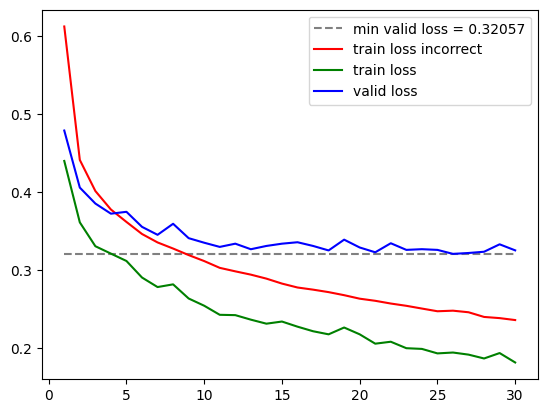

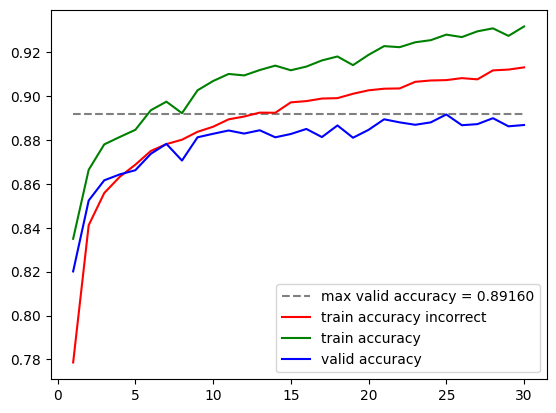

In [ ]:
# numero de epocas: 30 (no es un grafico necesario porque se puede deducir facilmente de los otros graficos)
n_epochs = 30
learning_rate = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Avaliable device: cuda
Epoch 1/100: train loss=0.434, valid loss=0.471, train accuracy=0.840%, valid accuracy=0.825%
Epoch 2/100: train loss=0.356, valid loss=0.404, train accuracy=0.869%, valid accuracy=0.851%
Epoch 3/100: train loss=0.347, valid loss=0.399, train accuracy=0.870%, valid accuracy=0.855%
Epoch 4/100: train loss=0.325, valid loss=0.383, train accuracy=0.877%, valid accuracy=0.856%
Epoch 5/100: train loss=0.293, valid loss=0.353, train accuracy=0.892%, valid accuracy=0.872%
Epoch 6/100: train loss=0.282, valid loss=0.351, train accuracy=0.894%, valid accuracy=0.872%
Epoch 7/100: train loss=0.273, valid loss=0.346, train accuracy=0.899%, valid accuracy=0.876%
Epoch 8/100: train loss=0.270, valid loss=0.343, train accuracy=0.900%, valid accuracy=0.879%
Epoch 9/100: train loss=0.261, valid loss=0.340, train accuracy=0.903%, valid accuracy=0.880%
Epoch 10/100: train loss=0.262, valid loss=0.339, train accuracy=0.902%, valid accuracy=0.877%
Epoch 11/100: train loss=0.252, vali

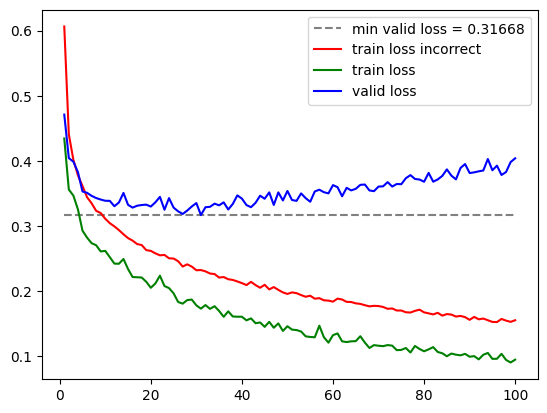

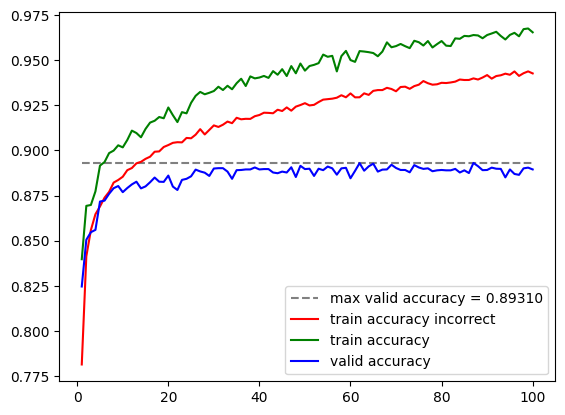

In [ ]:
# numero de epocas: 100 (no es un grafico necesario porque se puede deducir facilmente de los otros graficos)
n_epochs = 100
learning_rate = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Avaliable device: cuda
Epoch 1/50: train loss=0.391, valid loss=0.432, train accuracy=0.860%, valid accuracy=0.842%
Epoch 2/50: train loss=0.355, valid loss=0.407, train accuracy=0.868%, valid accuracy=0.852%
Epoch 3/50: train loss=0.354, valid loss=0.413, train accuracy=0.868%, valid accuracy=0.848%
Epoch 4/50: train loss=0.308, valid loss=0.373, train accuracy=0.888%, valid accuracy=0.867%
Epoch 5/50: train loss=0.281, valid loss=0.360, train accuracy=0.896%, valid accuracy=0.869%
Epoch 6/50: train loss=0.262, valid loss=0.340, train accuracy=0.905%, valid accuracy=0.879%
Epoch 7/50: train loss=0.254, valid loss=0.349, train accuracy=0.906%, valid accuracy=0.876%
Epoch 8/50: train loss=0.254, valid loss=0.349, train accuracy=0.905%, valid accuracy=0.875%
Epoch 9/50: train loss=0.240, valid loss=0.347, train accuracy=0.909%, valid accuracy=0.878%
Epoch 10/50: train loss=0.227, valid loss=0.339, train accuracy=0.915%, valid accuracy=0.878%
Epoch 11/50: train loss=0.214, valid loss=0.34

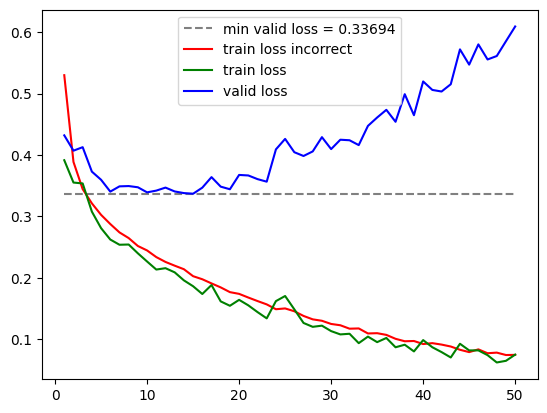

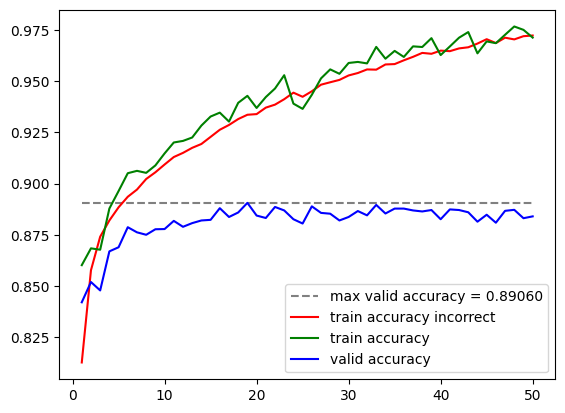

In [ ]:
# Flor -> Dropout - Tamaño de lotes

# Parametros - Caso dropout 0.0
n_epochs = 50
learning_rate = 1e-3
dropout = 0.00
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Avaliable device: cuda
Epoch 1/50: train loss=0.467, valid loss=0.495, train accuracy=0.829%, valid accuracy=0.818%
Epoch 2/50: train loss=0.435, valid loss=0.472, train accuracy=0.834%, valid accuracy=0.820%
Epoch 3/50: train loss=0.383, valid loss=0.426, train accuracy=0.858%, valid accuracy=0.843%
Epoch 4/50: train loss=0.376, valid loss=0.419, train accuracy=0.857%, valid accuracy=0.843%
Epoch 5/50: train loss=0.365, valid loss=0.415, train accuracy=0.863%, valid accuracy=0.848%
Epoch 6/50: train loss=0.348, valid loss=0.400, train accuracy=0.874%, valid accuracy=0.854%
Epoch 7/50: train loss=0.337, valid loss=0.389, train accuracy=0.874%, valid accuracy=0.856%
Epoch 8/50: train loss=0.342, valid loss=0.394, train accuracy=0.871%, valid accuracy=0.856%
Epoch 9/50: train loss=0.332, valid loss=0.388, train accuracy=0.875%, valid accuracy=0.859%
Epoch 10/50: train loss=0.326, valid loss=0.383, train accuracy=0.880%, valid accuracy=0.858%
Epoch 11/50: train loss=0.321, valid loss=0.38

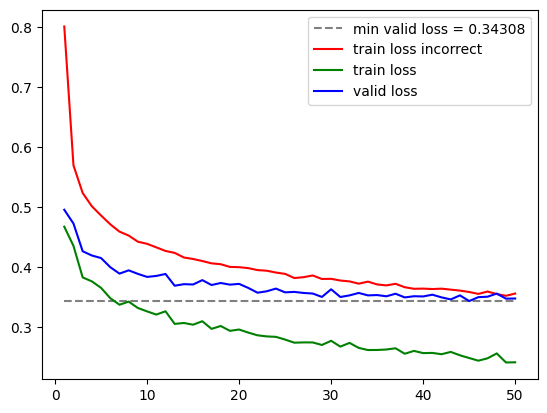

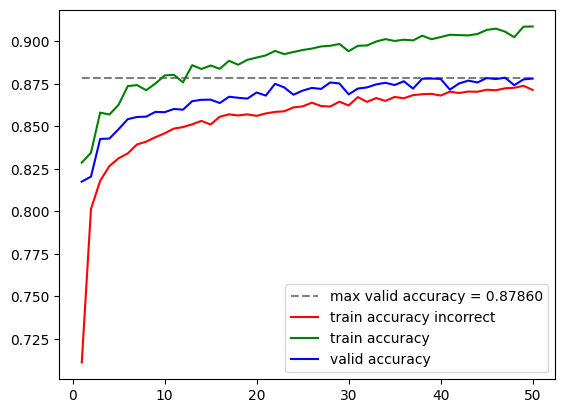

In [ ]:
# Parametros - Caso dropout 0.5
n_epochs = 50
learning_rate = 1e-3
dropout = 0.5
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.legend()
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.legend()
plt.show()

Avaliable device: cpu
Epoch 1/50: train loss=0.412, valid loss=0.455, train accuracy=0.848%, valid accuracy=0.836%
Epoch 2/50: train loss=0.359, valid loss=0.410, train accuracy=0.864%, valid accuracy=0.852%
Epoch 3/50: train loss=0.334, valid loss=0.387, train accuracy=0.876%, valid accuracy=0.859%
Epoch 4/50: train loss=0.326, valid loss=0.389, train accuracy=0.878%, valid accuracy=0.861%
Epoch 5/50: train loss=0.312, valid loss=0.384, train accuracy=0.883%, valid accuracy=0.862%
Epoch 6/50: train loss=0.296, valid loss=0.368, train accuracy=0.886%, valid accuracy=0.867%
Epoch 7/50: train loss=0.293, valid loss=0.367, train accuracy=0.888%, valid accuracy=0.868%
Epoch 8/50: train loss=0.280, valid loss=0.361, train accuracy=0.894%, valid accuracy=0.871%
Epoch 9/50: train loss=0.276, valid loss=0.357, train accuracy=0.897%, valid accuracy=0.872%
Epoch 10/50: train loss=0.276, valid loss=0.368, train accuracy=0.892%, valid accuracy=0.868%
Epoch 11/50: train loss=0.262, valid loss=0.358

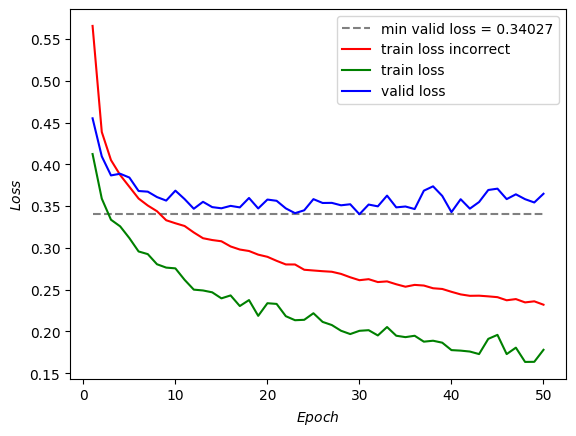

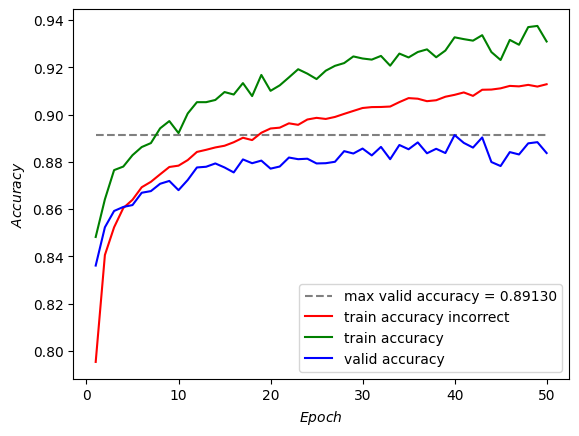

In [ ]:
# Parametros - Caso batch_size 20
n_epochs = 50
learning_rate = 1e-3
dropout = 0.2
batch_size = 20
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.xlabel('$Epoch$')
plt.ylabel('$Loss$')
plt.legend()
plt.savefig("batch1.png")
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.xlabel('$Epoch$')
plt.ylabel('$Accuracy$')
plt.legend()
plt.savefig("batch2.png")
plt.show()

Avaliable device: cpu
Epoch 1/50: train loss=0.683, valid loss=0.698, train accuracy=0.750%, valid accuracy=0.741%
Epoch 2/50: train loss=0.547, valid loss=0.569, train accuracy=0.798%, valid accuracy=0.787%
Epoch 3/50: train loss=0.477, valid loss=0.505, train accuracy=0.825%, valid accuracy=0.811%
Epoch 4/50: train loss=0.444, valid loss=0.476, train accuracy=0.837%, valid accuracy=0.825%
Epoch 5/50: train loss=0.412, valid loss=0.447, train accuracy=0.851%, valid accuracy=0.837%
Epoch 6/50: train loss=0.395, valid loss=0.432, train accuracy=0.857%, valid accuracy=0.841%
Epoch 7/50: train loss=0.375, valid loss=0.416, train accuracy=0.865%, valid accuracy=0.849%
Epoch 8/50: train loss=0.362, valid loss=0.405, train accuracy=0.867%, valid accuracy=0.854%
Epoch 9/50: train loss=0.350, valid loss=0.395, train accuracy=0.872%, valid accuracy=0.858%
Epoch 10/50: train loss=0.345, valid loss=0.392, train accuracy=0.873%, valid accuracy=0.858%
Epoch 11/50: train loss=0.329, valid loss=0.377

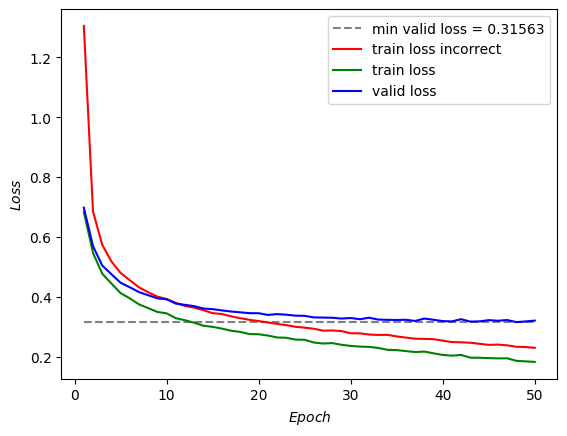

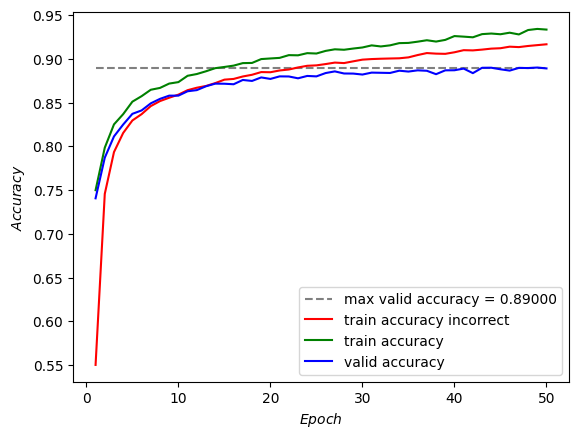

In [ ]:
# Parametros - Caso batch_size 2.000
n_epochs = 50
learning_rate = 1e-3
dropout = 0.2
batch_size = 2000
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

list_train_loss_incorrect = []
list_train_accuracy_incorrect = []
list_train_loss = []
list_train_accuracy = []
list_valid_loss = []
list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle = True)
function_loss = nn.CrossEntropyLoss()
model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device(avaliable_device())
model = model.to(device)

print(f"Avaliable device: {device}")

t_i = time.time()
for epoch in range(n_epochs):
    # entreno con los ejemplos
    train_loss_incorrect, train_accuracy_incorrect = train(train_loader, model, function_loss, optimizer)
    list_train_loss_incorrect.append(train_loss_incorrect)
    list_train_accuracy_incorrect.append(train_accuracy_incorrect)
    # valido con el conjunto de ejemplo
    train_loss, train_accuracy = eval(train_loader, model, function_loss)
    list_train_loss.append(train_loss)
    list_train_accuracy.append(train_accuracy)
    # valido con el conjunto de testeo
    valid_loss, valid_accuracy = eval(valid_loader, model, function_loss)
    list_valid_loss.append(valid_loss)
    list_valid_accuracy.append(valid_accuracy)

    print(  "Epoch {}/{}:".format(epoch+1, n_epochs),
            "train loss={:.3f},".format(train_loss),
            "valid loss={:.3f},".format(valid_loss),
            "train accuracy={:.3f}%,".format(train_accuracy),
            "valid accuracy={:.3f}%".format(valid_accuracy))

print(f"\nTiempo de ejecucion: {(time.time()-t_i)/60:.2f}")

epoch = [i for i in range(1, n_epochs+1)]
min_loss = min(list_valid_loss)
plt.plot(epoch, np.full(n_epochs, min_loss), label=f"min valid loss = {min_loss:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_loss_incorrect, label='train loss incorrect', c='red')
plt.plot(epoch, list_train_loss, label='train loss', c='green')
plt.plot(epoch, list_valid_loss, label='valid loss', c='blue')
plt.xlabel('$Epoch$')
plt.ylabel('$Loss$')
plt.legend()
plt.savefig("batch3.png")
plt.show()

max_acc = max(list_valid_accuracy)
plt.plot(epoch, np.full(n_epochs,max_acc), label=f"max valid accuracy = {max_acc:.5f}", c='gray', linestyle="--")
plt.plot(epoch, list_train_accuracy_incorrect, label='train accuracy incorrect', c='red')
plt.plot(epoch, list_train_accuracy, label='train accuracy', c='green')
plt.plot(epoch, list_valid_accuracy, label='valid accuracy', c='blue')
plt.xlabel('$Epoch$')
plt.ylabel('$Accuracy$')
plt.legend()
plt.savefig("batch4.png")
plt.show()

In [ ]:
# ==== Análisis de distintos valores de Dropout ====

n_epochs = 50
learning_rate = 1e-3
batch_size = 100
input_layer_size = 28*28   # no cambiar
output_layer_size = 10     # no cambiar

# Arquitectura fija
hidden_layer_1_size = 128
hidden_layer_2_size = 64

# Distintos valores de dropout
c1_dropout = 0.00
c2_dropout = 0.20
c3_dropout = 0.50

# Listas de resultados
c1_list_train_loss_incorrect = []
c1_list_train_accuracy_incorrect = []
c1_list_train_loss = []
c1_list_train_accuracy = []
c1_list_valid_loss = []
c1_list_valid_accuracy = []

c2_list_train_loss_incorrect = []
c2_list_train_accuracy_incorrect = []
c2_list_train_loss = []
c2_list_train_accuracy = []
c2_list_valid_loss = []
c2_list_valid_accuracy = []

c3_list_train_loss_incorrect = []
c3_list_train_accuracy_incorrect = []
c3_list_train_loss = []
c3_list_train_accuracy = []
c3_list_valid_loss = []
c3_list_valid_accuracy = []

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle=True)

device = torch.device(avaliable_device())
print(f"Avaliable device: {device}")

# ==== CASO 1: Dropout 0.00 ====
c1_function_loss = nn.CrossEntropyLoss()
c1_model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, c1_dropout)
c1_optimizer = torch.optim.Adam(c1_model.parameters(), lr=learning_rate)
c1_model = c1_model.to(device)

print(f"\n===== ENTRENANDO MODELO CON DROPOUT = {c1_dropout} =====")
t_i = time.time()
for epoch in range(n_epochs):
    c1_train_loss_incorrect, c1_train_accuracy_incorrect = train(train_loader, c1_model, c1_function_loss, c1_optimizer)
    c1_list_train_loss_incorrect.append(c1_train_loss_incorrect)
    c1_list_train_accuracy_incorrect.append(c1_train_accuracy_incorrect)

    c1_train_loss, c1_train_accuracy = eval(train_loader, c1_model, c1_function_loss)
    c1_list_train_loss.append(c1_train_loss)
    c1_list_train_accuracy.append(c1_train_accuracy)

    c1_valid_loss, c1_valid_accuracy = eval(valid_loader, c1_model, c1_function_loss)
    c1_list_valid_loss.append(c1_valid_loss)
    c1_list_valid_accuracy.append(c1_valid_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}: train loss={c1_train_loss:.3f}, valid loss={c1_valid_loss:.3f}, "
          f"train acc={c1_train_accuracy:.3f}%, valid acc={c1_valid_accuracy:.3f}%")

print(f"\nTiempo de ejecución: {(time.time()-t_i)/60:.2f} min")


# ==== CASO 2: Dropout 0.20 ====
c2_function_loss = nn.CrossEntropyLoss()
c2_model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, c2_dropout)
c2_optimizer = torch.optim.Adam(c2_model.parameters(), lr=learning_rate)
c2_model = c2_model.to(device)

print(f"\n===== ENTRENANDO MODELO CON DROPOUT = {c2_dropout} =====")
t_i = time.time()
for epoch in range(n_epochs):
    c2_train_loss_incorrect, c2_train_accuracy_incorrect = train(train_loader, c2_model, c2_function_loss, c2_optimizer)
    c2_list_train_loss_incorrect.append(c2_train_loss_incorrect)
    c2_list_train_accuracy_incorrect.append(c2_train_accuracy_incorrect)

    c2_train_loss, c2_train_accuracy = eval(train_loader, c2_model, c2_function_loss)
    c2_list_train_loss.append(c2_train_loss)
    c2_list_train_accuracy.append(c2_train_accuracy)

    c2_valid_loss, c2_valid_accuracy = eval(valid_loader, c2_model, c2_function_loss)
    c2_list_valid_loss.append(c2_valid_loss)
    c2_list_valid_accuracy.append(c2_valid_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}: train loss={c2_train_loss:.3f}, valid loss={c2_valid_loss:.3f}, "
          f"train acc={c2_train_accuracy:.3f}%, valid acc={c2_valid_accuracy:.3f}%")

print(f"\nTiempo de ejecución: {(time.time()-t_i)/60:.2f} min")


# ==== CASO 3: Dropout 0.50 ====
c3_function_loss = nn.CrossEntropyLoss()
c3_model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, c3_dropout)
c3_optimizer = torch.optim.Adam(c3_model.parameters(), lr=learning_rate)
c3_model = c3_model.to(device)

print(f"\n===== ENTRENANDO MODELO CON DROPOUT = {c3_dropout} =====")
t_i = time.time()
for epoch in range(n_epochs):
    c3_train_loss_incorrect, c3_train_accuracy_incorrect = train(train_loader, c3_model, c3_function_loss, c3_optimizer)
    c3_list_train_loss_incorrect.append(c3_train_loss_incorrect)
    c3_list_train_accuracy_incorrect.append(c3_train_accuracy_incorrect)

    c3_train_loss, c3_train_accuracy = eval(train_loader, c3_model, c3_function_loss)
    c3_list_train_loss.append(c3_train_loss)
    c3_list_train_accuracy.append(c3_train_accuracy)

    c3_valid_loss, c3_valid_accuracy = eval(valid_loader, c3_model, c3_function_loss)
    c3_list_valid_loss.append(c3_valid_loss)
    c3_list_valid_accuracy.append(c3_valid_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}: train loss={c3_train_loss:.3f}, valid loss={c3_valid_loss:.3f}, "
          f"train acc={c3_train_accuracy:.3f}%, valid acc={c3_valid_accuracy:.3f}%")

print(f"\nTiempo de ejecución: {(time.time()-t_i)/60:.2f} min")


Avaliable device: cpu

===== ENTRENANDO MODELO CON DROPOUT = 0.0 =====
Epoch 1/50: train loss=0.396, valid loss=0.435, train acc=0.856%, valid acc=0.841%
Epoch 2/50: train loss=0.377, valid loss=0.426, train acc=0.859%, valid acc=0.844%
Epoch 3/50: train loss=0.338, valid loss=0.399, train acc=0.874%, valid acc=0.857%
Epoch 4/50: train loss=0.293, valid loss=0.356, train acc=0.893%, valid acc=0.872%
Epoch 5/50: train loss=0.306, valid loss=0.378, train acc=0.883%, valid acc=0.864%
Epoch 6/50: train loss=0.269, valid loss=0.350, train acc=0.901%, valid acc=0.875%
Epoch 7/50: train loss=0.250, valid loss=0.337, train acc=0.909%, valid acc=0.878%
Epoch 8/50: train loss=0.233, valid loss=0.334, train acc=0.915%, valid acc=0.884%
Epoch 9/50: train loss=0.227, valid loss=0.334, train acc=0.915%, valid acc=0.878%
Epoch 10/50: train loss=0.227, valid loss=0.345, train acc=0.914%, valid acc=0.879%
Epoch 11/50: train loss=0.220, valid loss=0.341, train acc=0.918%, valid acc=0.878%
Epoch 12/50: t

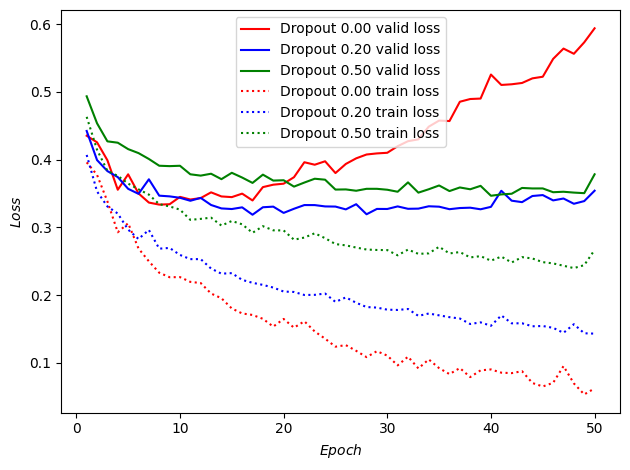

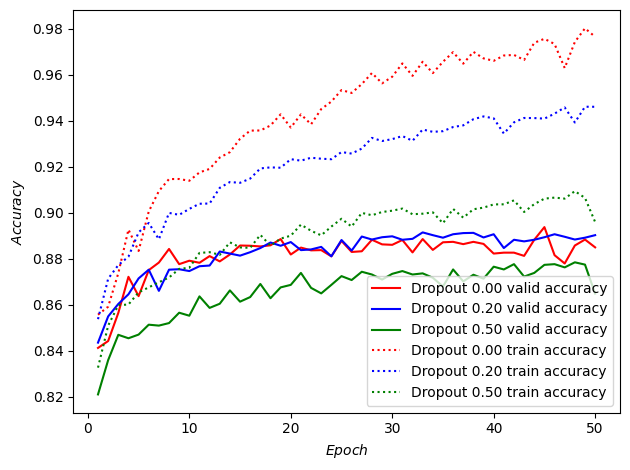

In [ ]:
# ==== Gráficos para los distintos valores de dropout ====

epoch = [i for i in range(1, n_epochs+1)]

# ======= LOSS =======
plt.plot(epoch, c1_list_valid_loss, label='Dropout 0.00 valid loss', linestyle="-", c='red')
plt.plot(epoch, c2_list_valid_loss, label='Dropout 0.20 valid loss', linestyle="-", c='blue')
plt.plot(epoch, c3_list_valid_loss, label='Dropout 0.50 valid loss', linestyle="-", c='green')

plt.plot(epoch, c1_list_train_loss, label='Dropout 0.00 train loss', linestyle=":", c='red')
plt.plot(epoch, c2_list_train_loss, label='Dropout 0.20 train loss', linestyle=":", c='blue')
plt.plot(epoch, c3_list_train_loss, label='Dropout 0.50 train loss', linestyle=":", c='green')

plt.xlabel('$Epoch$')
plt.ylabel('$Loss$')
plt.legend()
plt.tight_layout()
plt.savefig("dropout_loss.png")
plt.show()


# ======= ACCURACY =======
plt.plot(epoch, c1_list_valid_accuracy, label='Dropout 0.00 valid accuracy', linestyle="-", c='red')
plt.plot(epoch, c2_list_valid_accuracy, label='Dropout 0.20 valid accuracy', linestyle="-", c='blue')
plt.plot(epoch, c3_list_valid_accuracy, label='Dropout 0.50 valid accuracy', linestyle="-", c='green')

plt.plot(epoch, c1_list_train_accuracy, label='Dropout 0.00 train accuracy', linestyle=":", c='red')
plt.plot(epoch, c2_list_train_accuracy, label='Dropout 0.20 train accuracy', linestyle=":", c='blue')
plt.plot(epoch, c3_list_train_accuracy, label='Dropout 0.50 train accuracy', linestyle=":", c='green')

plt.xlabel('$Epoch$')
plt.ylabel('$Accuracy$')
plt.legend()
plt.tight_layout()
plt.savefig("dropout_accuracy.png")
plt.show()


In [ ]:
# ==== Análisis de distintos valores de batch size ====

n_epochs = 50
learning_rate = 1e-3
dropout = 0.2   # fijo
input_layer_size = 28*28   # no cambiar
output_layer_size = 10     # no cambiar

# Arquitectura fija
hidden_layer_1_size = 128
hidden_layer_2_size = 64

# Distintos tamaños de batch
c1_batch_size = 20
c2_batch_size = 100
c3_batch_size = 2000

# Listas de resultados
c1_list_train_loss_incorrect = []
c1_list_train_accuracy_incorrect = []
c1_list_train_loss = []
c1_list_train_accuracy = []
c1_list_valid_loss = []
c1_list_valid_accuracy = []

c2_list_train_loss_incorrect = []
c2_list_train_accuracy_incorrect = []
c2_list_train_loss = []
c2_list_train_accuracy = []
c2_list_valid_loss = []
c2_list_valid_accuracy = []

c3_list_train_loss_incorrect = []
c3_list_train_accuracy_incorrect = []
c3_list_train_loss = []
c3_list_train_accuracy = []
c3_list_valid_loss = []
c3_list_valid_accuracy = []

device = torch.device(avaliable_device())
print(f"Avaliable device: {device}")

# ==== CASO 1: Batch size 20 ====
train_loader = torch.utils.data.DataLoader(train_set, c1_batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, c1_batch_size, shuffle=True)

c1_function_loss = nn.CrossEntropyLoss()
c1_model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
c1_optimizer = torch.optim.Adam(c1_model.parameters(), lr=learning_rate)
c1_model = c1_model.to(device)

print(f"\n===== ENTRENANDO MODELO CON BATCH SIZE = {c1_batch_size} =====")
t_i = time.time()
for epoch in range(n_epochs):
    c1_train_loss_incorrect, c1_train_accuracy_incorrect = train(train_loader, c1_model, c1_function_loss, c1_optimizer)
    c1_list_train_loss_incorrect.append(c1_train_loss_incorrect)
    c1_list_train_accuracy_incorrect.append(c1_train_accuracy_incorrect)

    c1_train_loss, c1_train_accuracy = eval(train_loader, c1_model, c1_function_loss)
    c1_list_train_loss.append(c1_train_loss)
    c1_list_train_accuracy.append(c1_train_accuracy)

    c1_valid_loss, c1_valid_accuracy = eval(valid_loader, c1_model, c1_function_loss)
    c1_list_valid_loss.append(c1_valid_loss)
    c1_list_valid_accuracy.append(c1_valid_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}: train loss={c1_train_loss:.3f}, valid loss={c1_valid_loss:.3f}, "
          f"train acc={c1_train_accuracy:.3f}%, valid acc={c1_valid_accuracy:.3f}%")

print(f"\nTiempo de ejecución: {(time.time()-t_i)/60:.2f} min")


# ==== CASO 2: Batch size 100 ====
train_loader = torch.utils.data.DataLoader(train_set, c2_batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, c2_batch_size, shuffle=True)

c2_function_loss = nn.CrossEntropyLoss()
c2_model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
c2_optimizer = torch.optim.Adam(c2_model.parameters(), lr=learning_rate)
c2_model = c2_model.to(device)

print(f"\n===== ENTRENANDO MODELO CON BATCH SIZE = {c2_batch_size} =====")
t_i = time.time()
for epoch in range(n_epochs):
    c2_train_loss_incorrect, c2_train_accuracy_incorrect = train(train_loader, c2_model, c2_function_loss, c2_optimizer)
    c2_list_train_loss_incorrect.append(c2_train_loss_incorrect)
    c2_list_train_accuracy_incorrect.append(c2_train_accuracy_incorrect)

    c2_train_loss, c2_train_accuracy = eval(train_loader, c2_model, c2_function_loss)
    c2_list_train_loss.append(c2_train_loss)
    c2_list_train_accuracy.append(c2_train_accuracy)

    c2_valid_loss, c2_valid_accuracy = eval(valid_loader, c2_model, c2_function_loss)
    c2_list_valid_loss.append(c2_valid_loss)
    c2_list_valid_accuracy.append(c2_valid_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}: train loss={c2_train_loss:.3f}, valid loss={c2_valid_loss:.3f}, "
          f"train acc={c2_train_accuracy:.3f}%, valid acc={c2_valid_accuracy:.3f}%")

print(f"\nTiempo de ejecución: {(time.time()-t_i)/60:.2f} min")


# ==== CASO 3: Batch size 2000 ====
train_loader = torch.utils.data.DataLoader(train_set, c3_batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, c3_batch_size, shuffle=True)

c3_function_loss = nn.CrossEntropyLoss()
c3_model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout)
c3_optimizer = torch.optim.Adam(c3_model.parameters(), lr=learning_rate)
c3_model = c3_model.to(device)

print(f"\n===== ENTRENANDO MODELO CON BATCH SIZE = {c3_batch_size} =====")
t_i = time.time()
for epoch in range(n_epochs):
    c3_train_loss_incorrect, c3_train_accuracy_incorrect = train(train_loader, c3_model, c3_function_loss, c3_optimizer)
    c3_list_train_loss_incorrect.append(c3_train_loss_incorrect)
    c3_list_train_accuracy_incorrect.append(c3_train_accuracy_incorrect)

    c3_train_loss, c3_train_accuracy = eval(train_loader, c3_model, c3_function_loss)
    c3_list_train_loss.append(c3_train_loss)
    c3_list_train_accuracy.append(c3_train_accuracy)

    c3_valid_loss, c3_valid_accuracy = eval(valid_loader, c3_model, c3_function_loss)
    c3_list_valid_loss.append(c3_valid_loss)
    c3_list_valid_accuracy.append(c3_valid_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}: train loss={c3_train_loss:.3f}, valid loss={c3_valid_loss:.3f}, "
          f"train acc={c3_train_accuracy:.3f}%, valid acc={c3_valid_accuracy:.3f}%")

print(f"\nTiempo de ejecución: {(time.time()-t_i)/60:.2f} min")


Avaliable device: cpu

===== ENTRENANDO MODELO CON BATCH SIZE = 20 =====
Epoch 1/50: train loss=0.387, valid loss=0.428, train acc=0.859%, valid acc=0.846%
Epoch 2/50: train loss=0.363, valid loss=0.416, train acc=0.868%, valid acc=0.850%
Epoch 3/50: train loss=0.344, valid loss=0.406, train acc=0.869%, valid acc=0.850%
Epoch 4/50: train loss=0.327, valid loss=0.389, train acc=0.878%, valid acc=0.862%
Epoch 5/50: train loss=0.302, valid loss=0.369, train acc=0.886%, valid acc=0.865%
Epoch 6/50: train loss=0.291, valid loss=0.366, train acc=0.890%, valid acc=0.865%
Epoch 7/50: train loss=0.283, valid loss=0.363, train acc=0.893%, valid acc=0.871%
Epoch 8/50: train loss=0.279, valid loss=0.364, train acc=0.895%, valid acc=0.872%
Epoch 9/50: train loss=0.267, valid loss=0.355, train acc=0.900%, valid acc=0.875%
Epoch 10/50: train loss=0.264, valid loss=0.347, train acc=0.901%, valid acc=0.875%
Epoch 11/50: train loss=0.260, valid loss=0.354, train acc=0.902%, valid acc=0.875%
Epoch 12/50:

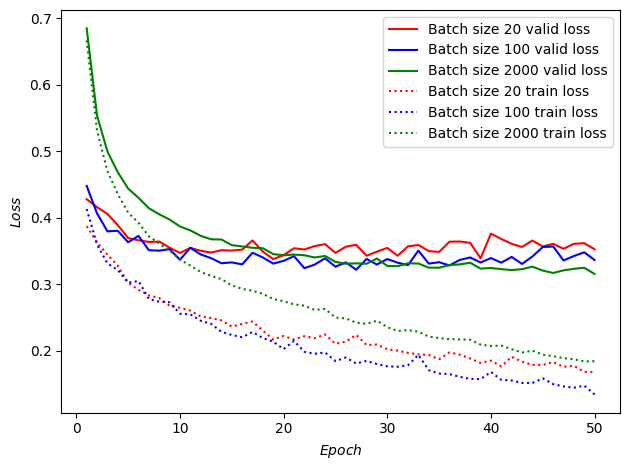

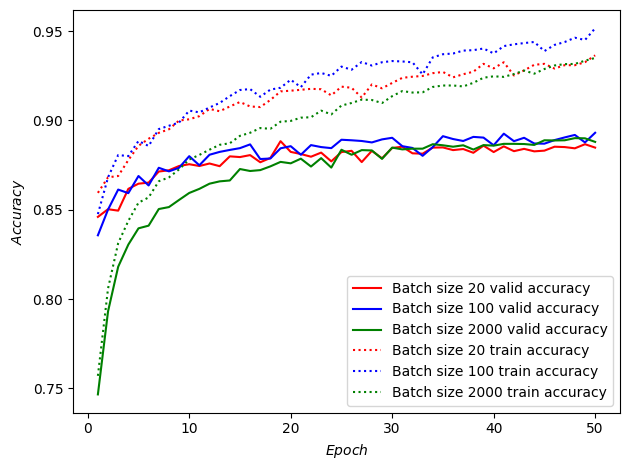

In [ ]:
# ==== Gráficos para los distintos valores de batch size ====

epoch = [i for i in range(1, n_epochs+1)]

# ======= LOSS =======
plt.plot(epoch, c1_list_valid_loss, label='Batch size 20 valid loss', linestyle="-", c='red')
plt.plot(epoch, c2_list_valid_loss, label='Batch size 100 valid loss', linestyle="-", c='blue')
plt.plot(epoch, c3_list_valid_loss, label='Batch size 2000 valid loss', linestyle="-", c='green')

plt.plot(epoch, c1_list_train_loss, label='Batch size 20 train loss', linestyle=":", c='red')
plt.plot(epoch, c2_list_train_loss, label='Batch size 100 train loss', linestyle=":", c='blue')
plt.plot(epoch, c3_list_train_loss, label='Batch size 2000 train loss', linestyle=":", c='green')

plt.xlabel('$Epoch$')
plt.ylabel('$Loss$')
plt.legend()
plt.tight_layout()
plt.savefig("batch_loss.png")
plt.show()


# ======= ACCURACY =======
plt.plot(epoch, c1_list_valid_accuracy, label='Batch size 20 valid accuracy', linestyle="-", c='red')
plt.plot(epoch, c2_list_valid_accuracy, label='Batch size 100 valid accuracy', linestyle="-", c='blue')
plt.plot(epoch, c3_list_valid_accuracy, label='Batch size 2000 valid accuracy', linestyle="-", c='green')

plt.plot(epoch, c1_list_train_accuracy, label='Batch size 20 train accuracy', linestyle=":", c='red')
plt.plot(epoch, c2_list_train_accuracy, label='Batch size 100 train accuracy', linestyle=":", c='blue')
plt.plot(epoch, c3_list_train_accuracy, label='Batch size 2000 train accuracy', linestyle=":", c='green')

plt.xlabel('$Epoch$')
plt.ylabel('$Accuracy$')
plt.legend()
plt.tight_layout()
plt.savefig("batch_accuracy.png")
plt.show()


Dispositivo disponible: cuda

Entrenando con Adam (lr=0.001)...
Adam (lr=0.001) | Epoch 1/100 | Train loss=0.607 | Valid loss=0.459 | Train acc=0.78% | Valid acc=0.83%
Adam (lr=0.001) | Epoch 2/100 | Train loss=0.437 | Valid loss=0.404 | Train acc=0.84% | Valid acc=0.85%
Adam (lr=0.001) | Epoch 3/100 | Train loss=0.399 | Valid loss=0.389 | Train acc=0.86% | Valid acc=0.86%
Adam (lr=0.001) | Epoch 4/100 | Train loss=0.377 | Valid loss=0.389 | Train acc=0.86% | Valid acc=0.85%
Adam (lr=0.001) | Epoch 5/100 | Train loss=0.358 | Valid loss=0.365 | Train acc=0.87% | Valid acc=0.86%
Adam (lr=0.001) | Epoch 6/100 | Train loss=0.343 | Valid loss=0.356 | Train acc=0.88% | Valid acc=0.87%
Adam (lr=0.001) | Epoch 7/100 | Train loss=0.335 | Valid loss=0.351 | Train acc=0.88% | Valid acc=0.87%
Adam (lr=0.001) | Epoch 8/100 | Train loss=0.322 | Valid loss=0.353 | Train acc=0.88% | Valid acc=0.87%
Adam (lr=0.001) | Epoch 9/100 | Train loss=0.315 | Valid loss=0.344 | Train acc=0.88% | Valid acc=0.87%


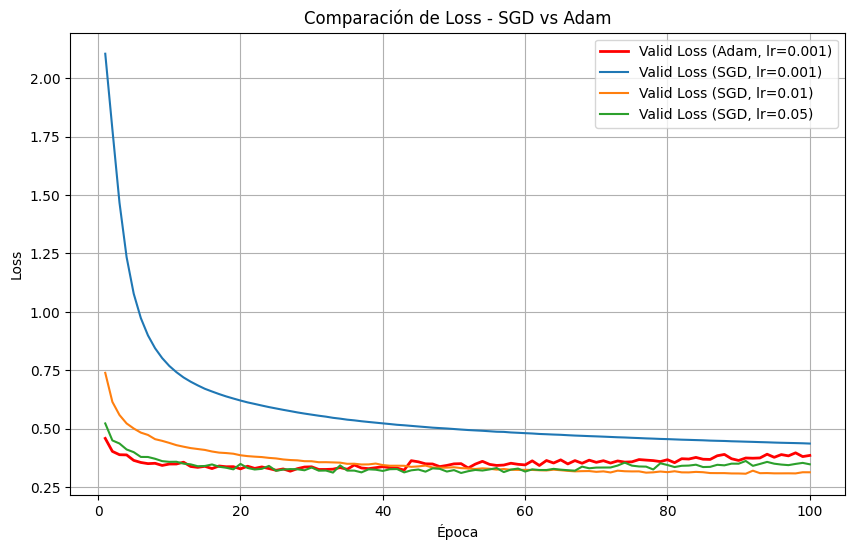

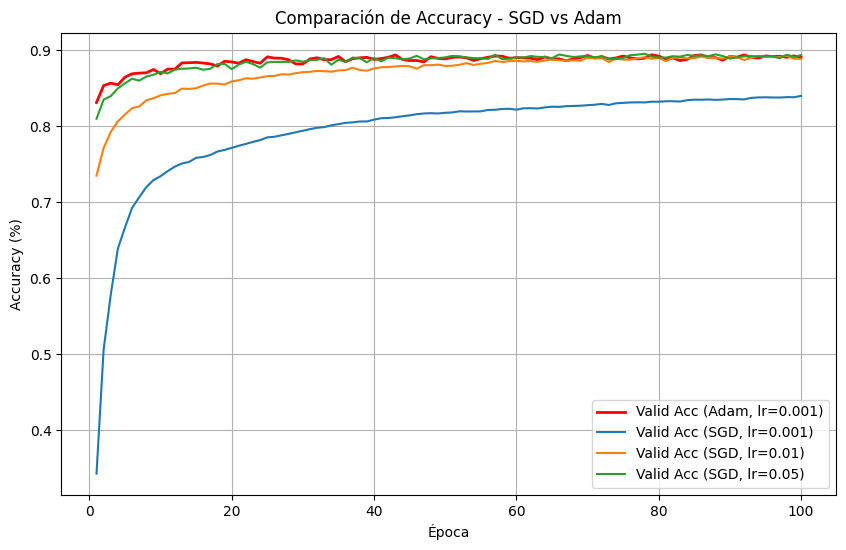

In [6]:
# ===========================
# COMPARACIÓN SGD vs ADAM
# ===========================

n_epochs = 100
learning_rates_sgd = [1e-3, 1e-2, 5e-2]   # tres learning rates para SGD
learning_rate_adam = 1e-3
dropout = 0.2
batch_size = 100
input_layer_size = 28*28   # no cambiar
hidden_layer_1_size = 128
hidden_layer_2_size = 64
output_layer_size = 10     # no cambiar

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size, shuffle=True)
function_loss = nn.CrossEntropyLoss()
device = torch.device(avaliable_device())

# =====================
# Función para entrenar y evaluar un modelo
# =====================
def run_training(optimizer_name, lr):
    model = NeuralNetwork(input_layer_size, hidden_layer_1_size, hidden_layer_2_size, output_layer_size, dropout).to(device)

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("Optimizador no reconocido")

    list_train_loss, list_valid_loss = [], []
    list_train_acc, list_valid_acc = [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train(train_loader, model, function_loss, optimizer)
        valid_loss, valid_acc = eval(valid_loader, model, function_loss)

        list_train_loss.append(train_loss)
        list_valid_loss.append(valid_loss)
        list_train_acc.append(train_acc)
        list_valid_acc.append(valid_acc)

        print(f"{optimizer_name} (lr={lr}) | Epoch {epoch+1}/{n_epochs} | "
              f"Train loss={train_loss:.3f} | Valid loss={valid_loss:.3f} | "
              f"Train acc={train_acc:.2f}% | Valid acc={valid_acc:.2f}%")

    return list_train_loss, list_valid_loss, list_train_acc, list_valid_acc


# =====================
# Entrenar modelos
# =====================
print(f"Dispositivo disponible: {device}\n")

# Adam
print("Entrenando con Adam (lr=0.001)...")
train_loss_adam, valid_loss_adam, train_acc_adam, valid_acc_adam = run_training("Adam", learning_rate_adam)

# SGD con distintos learning rates
results_sgd = {}
for lr in learning_rates_sgd:
    print(f"\nEntrenando con SGD (lr={lr})...")
    results_sgd[lr] = run_training("SGD", lr)


# =====================
# Gráficos comparativos
# =====================
epochs = range(1, n_epochs+1)

# --- Gráfico de pérdida ---
plt.figure(figsize=(10,6))
plt.plot(epochs, valid_loss_adam, label='Valid Loss (Adam, lr=0.001)', color='red', linewidth=2)
for lr, (train_loss, valid_loss, _, _) in results_sgd.items():
    plt.plot(epochs, valid_loss, label=f'Valid Loss (SGD, lr={lr})')
plt.title('Comparación de Loss - SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfico de accuracy ---
plt.figure(figsize=(10,6))
plt.plot(epochs, valid_acc_adam, label='Valid Acc (Adam, lr=0.001)', color='red', linewidth=2)
for lr, (_, _, train_acc, valid_acc) in results_sgd.items():
    plt.plot(epochs, valid_acc, label=f'Valid Acc (SGD, lr={lr})')
plt.title('Comparación de Accuracy - SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


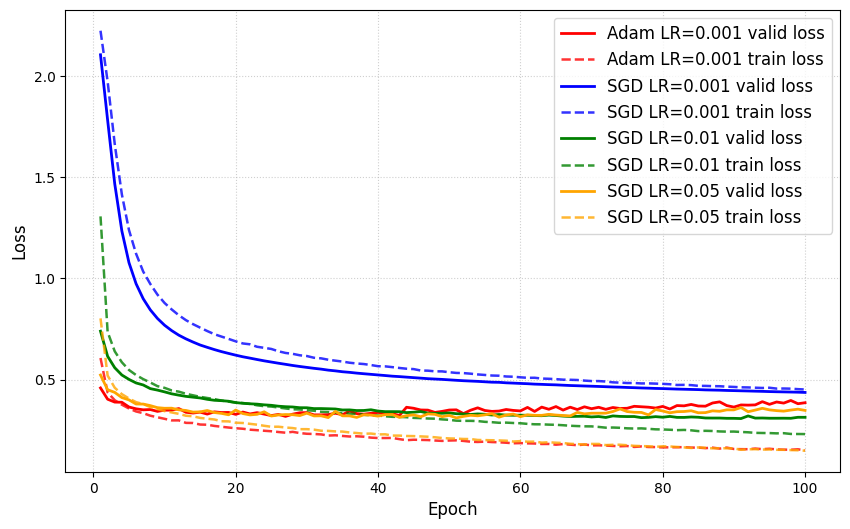

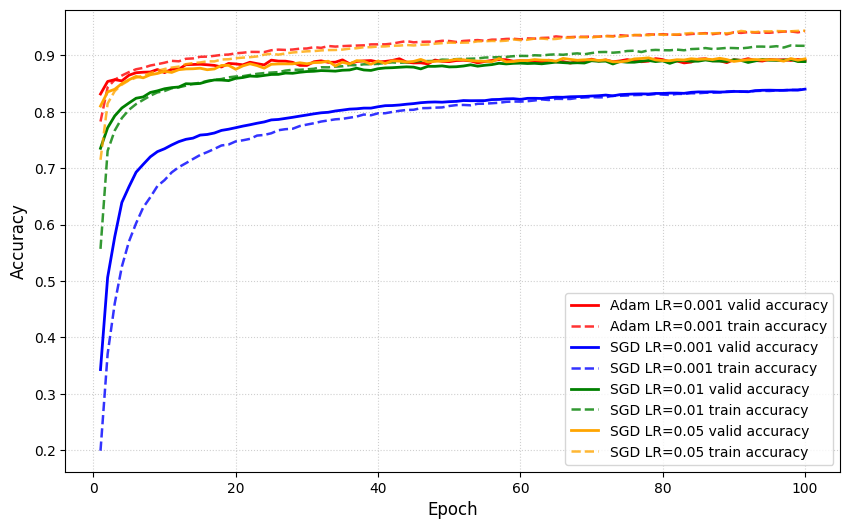

In [8]:
# =====================
# Gráficos más estéticos (línea punteada para train)
# =====================

epochs = range(1, n_epochs+1)

# Paleta de colores coherente
colors = {
    "Adam": "red",
    1e-3: "blue",
    1e-2: "green",
    5e-2: "orange"
}

# --- Gráfico de pérdida ---
plt.figure(figsize=(10,6))

# Adam
plt.plot(epochs, valid_loss_adam, label='Adam LR=0.001 valid loss',
         color=colors["Adam"], linewidth=2)
plt.plot(epochs, train_loss_adam, label='Adam LR=0.001 train loss',
         color=colors["Adam"], linestyle='--', linewidth=1.8, alpha=0.8)

# SGD
for lr, (train_loss, valid_loss, _, _) in results_sgd.items():
    plt.plot(epochs, valid_loss, label=f'SGD LR={lr} valid loss',
             color=colors[lr], linewidth=2)
    plt.plot(epochs, train_loss, label=f'SGD LR={lr} train loss',
             color=colors[lr], linestyle='--', linewidth=1.8, alpha=0.8)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- Gráfico de accuracy ---
plt.figure(figsize=(10,6))

# Adam
plt.plot(epochs, valid_acc_adam, label='Adam LR=0.001 valid accuracy',
         color=colors["Adam"], linewidth=2)
plt.plot(epochs, train_acc_adam, label='Adam LR=0.001 train accuracy',
         color=colors["Adam"], linestyle='--', linewidth=1.8, alpha=0.8)

# SGD
for lr, (_, _, train_acc, valid_acc) in results_sgd.items():
    plt.plot(epochs, valid_acc, label=f'SGD LR={lr} valid accuracy',
             color=colors[lr], linewidth=2)
    plt.plot(epochs, train_acc, label=f'SGD LR={lr} train accuracy',
             color=colors[lr], linestyle='--', linewidth=1.8, alpha=0.8)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
